Steve Brunton-Numerical integration with the rectangle and trapezoidal rules.


## Numerical Integration Methods

Various methods have been used to numerically approximate the integral of a function over a given interval:

### 1. Rectangle Rule

The rectangle rule is a simple method that estimates the area under a curve by summing the areas of rectangles of a specified width. Essentially, the function value at each subinterval (usually at the left or right endpoint) is taken as the height of a rectangle.

**Formula:**

For the Left Rectangle Rule:

$$\int_{a}^{b} f(x) \,dx \approx \sum_{i=0}^{n-1} f(x_i) \Delta x$$

For the Right Rectangle Rule:

$$\int_{a}^{b} f(x) \,dx \approx \sum_{i=1}^{n} f(x_i) \Delta x$$

Where $\Delta x = \frac{b-a}{n}$ and $x_i = a + i\Delta x$.

### 2. Trapezoidal Rule

The trapezoidal rule estimates the area under a curve more accurately by using trapezoids instead of rectangles. In each subinterval, the function values are evaluated at the two endpoints, and these two points are connected by a line segment to form a trapezoid.

**Formula:**

$$\int_{a}^{b} f(x) \,dx \approx \frac{\Delta x}{2} \sum_{i=0}^{n-1} [f(x_i) + f(x_{i+1})] = \frac{\Delta x}{2} [f(x_0) + 2\sum_{i=1}^{n-1} f(x_i) + f(x_n)]$$

### 3. Simpson's Rule

Simpson's rule uses a higher-order polynomial approximation for numerical integration. It approximates each pair of subintervals (covering two subintervals) with a parabola. This generally yields more accurate results than the rectangle and trapezoidal rules, but the number of intervals must be even (for the composite Simpson's 1/3 rule).

**Formula (for Composite Simpson's 1/3 Rule, n must be even):**

$$\int_{a}^{b} f(x) \,dx \approx \frac{\Delta x}{3} [f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + \dots + 2f(x_{n-2}) + 4f(x_{n-1}) + f(x_n)]$$

 $$\int_{a}^{b} f(x) \,dx \approx \frac{\Delta x}{3} [f(x_0) + f(x_n) + 4\sum_{i=1 \text{ (odd)}}^{n-1} f(x_i) + 2\sum_{i=2 \text{ (even)}}^{n-2} f(x_i)]$$

In [8]:
# import libraries
import numpy as np
from matplotlib import pyplot as plt

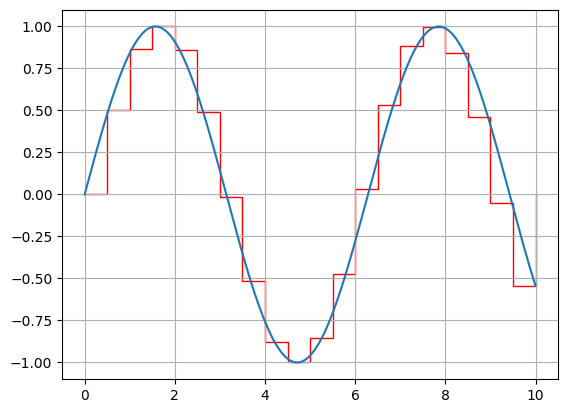

In [10]:
# define physical constants and time base
a = 0
b = 10
dxf = 0.01
xf = np.linspace(a, b, int(b / dxf))
yf = np.sin(xf)
plt.figure()
plt.grid(True)
plt.plot(xf, yf)

dxc = 0.5
xc = np.linspace(a, b, int(b / dxc))
edges = np.linspace(a, b, int(b / dxc) + 1, endpoint=True)
yc = np.sin(xc)
plt.stairs(yc, edges, color='r')
plt.grid(True)
plt.show()

In [12]:
n = len(xc)

# left-rectangle rule
area1 = 0
for i in range(n - 1):
    area1 = area1 + yc[i] * dxc
print(area1)

1.842605279599356


In [13]:
# right-rectangle rule
area2 = 0
for i in range(n - 1):
    area2 = area2 + yc[i + 1] * dxc
print(area2)

1.5705947241546712


In [14]:
# trapezoid rule
area3 = 0
for i in range(n - 1):
  area3 = area3 + (dxc / 2) * (yc[i] + yc[i + 1])
print(area3)

1.7066000018770136


In [15]:
# we can also use built in python functions
area1 = sum(yc[:-1]) * dxc;
area2 = sum(yc[1:]) * dxc;
area3 = np.trapz(yc, xc);
print(area1, area2, area3)
area3 = np.trapz(yc) * dxc;
print(area1, area2, area3)

1.842605279599356 1.5705947241546712 1.7964210546073829
1.842605279599356 1.5705947241546712 1.706600001877014


/tmp/ipykernel_1707/2063608786.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area3 = np.trapz(yc, xc);
/tmp/ipykernel_1707/2063608786.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area3 = np.trapz(yc) * dxc;


In [4]:
def rectangle_rule(y, dx):
    return np.sum(y) * dx

integral_rectangle = rectangle_rule(yf[:-1], dxf) # Using yf[:-1] for left Riemann sum
print(f"Integral using Rectangle Rule: {integral_rectangle}")

Integral using Rectangle Rule: 1.8399372221391903


In [5]:
def trapezoidal_rule(y, dx):
    return (np.sum(y) - (y[0] + y[-1]) / 2) * dx

integral_trapezoidal = trapezoidal_rule(yf, dxf)
print(f"Integral using Trapezoidal Rule: {integral_trapezoidal}")

Integral using Trapezoidal Rule: 1.8372171165847433


In [7]:
def simpsons_rule(y, dx):
    n = len(y) - 1 # number of intervals
    if n % 2 == 0: # n is even, standard composite Simpson's 1/3 rule
        # Formula: (dx/3) * [y0 + 4*y1 + 2*y2 + ... + 4*y(n-1) + yn]
        integral = dx / 3 * (y[0] + 2 * np.sum(y[2:n:2]) + 4 * np.sum(y[1:n:2]) + y[n])
    else: # n is odd, use Simpson's 1/3 rule for n-1 intervals and trapezoidal for the last
        # Apply Simpson's 1/3 rule to the first n-1 intervals (n points)
        # Note: y[n-1] is the last point for the Simpson's part
        integral_simpson = dx / 3 * (y[0] + 2 * np.sum(y[2:n-1:2]) + 4 * np.sum(y[1:n-1:2]) + y[n-1])
        # Apply Trapezoidal rule to the last interval (between y[n-1] and y[n])
        integral_trapezoid = dx / 2 * (y[n-1] + y[n])
        integral = integral_simpson + integral_trapezoid
    return integral

integral_simpson = simpsons_rule(yf, dxf)
print(f"Integral using Simpson's Rule: {integral_simpson}")

Integral using Simpson's Rule: 1.83723250272471
